# [LAB-09] 선형회귀ㅣ06-[PBT] 회귀모형 평가와 진단(실습코드).ipynb

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *

import numpy as np
from pandas import DataFrame, concat
from IPython.display import Markdown

# 성능 평가 지표 (직접 계산하지 않고 sklearn의 함수를 사용한다.)
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 체크포인트 데이터 로드 
전처리 단계가 하나씩 누적된 5개의 데이터셋을 불러온다.

In [2]:
df0 = load_data("boston_checkpoint_0")
df1 = load_data("boston_checkpoint_1")
df2 = load_data("boston_checkpoint_2")
df3 = load_data("boston_checkpoint_3")
df4 = load_data("boston_checkpoint_4")


📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 0 - 기준선 역할을 위해 라벨링과 더미변수 처리만 적용됨
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 1 - 라벨링 + 더미변수 + 로그변환
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 2 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 3 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체 + 다중공선성제거
📚 보스턴 주택 가격 데이터셋의 전처리 체크포인트 4 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체 + 다중공선성제거 + 스케일링


### 3. 분석 대상 정리 

In [3]:
# 종속변수 
target = "MEDV"

# 앞 단원에서 확인된 내용 
# 비교 대상 체크포인트 (아래로 갈수록 전처리가 하나씩 누적된다.)
checkpoints = {"0_기준선":df0, "1_로그변환":df1, "2_이상치대체":df2, "3_공선성제거":df3, "4_스케일링":df4}

# 종속변수(MEDV)에 log1p가 적용되었는지 여부 (체크포인트 1부터 적용됨)
log1p_y = {"0_기준선":False, "1_로그변환":True, "2_이상치대체":True, 
           "3_공선성제거":True, "4_스케일링":True}

# 로그변환(log)이 적용된 독립변수 -> 최종 모델의 회귀계수 해석에 사용한다.
log_x = ["CRIM", "DIS", "RAD", "LSTAT"]

# 로그1p변환(log1p)이 적용된 독립변수 -> 최종 모델의 회귀계수 해석에 사용한다.
log1p_x = ["ZN"]

# 반전 로그 변환이 적용된 독립변수 
reflect_x = ["B"]

### 4. 종속변수 척도 확인 
체크포인트 1 이후 부터 종속변수의 척도가 다름을 확인 

In [4]:
medv_scale = DataFrame()

for name in checkpoints:
    data = checkpoints[name] 
    medv_scale[name] = data[target].describe() # 복사된 데이터에서 종속변수의 기술통계량만 구함 

medv_scale.round(3)

,0_기준선,1_로그변환,2_이상치대체,3_공선성제거,4_스케일링
count,506.000,506.000,506.000,506.000,506.000
mean,22.533,3.035,3.035,3.035,3.035
std,9.197,0.409,0.409,0.409,0.409
min,5.000,1.609,1.609,1.609,1.609
25%,17.025,2.835,2.835,2.835,2.835
50%,21.200,3.054,3.054,3.054,3.054
75%,25.000,3.219,3.219,3.219,3.219
max,50.000,3.912,3.912,3.912,3.912


## #02. 체크포인트별 모델 적합 및 성능 비교 

### 1. 체크포인트마다 모델을 적합 (후진소거법 포함) 
예측값을 원본 척도(천 달러)로 되돌려 성능을 계산한다.

In [5]:
fits = {}
result = [] 

for c in checkpoints:
    data = checkpoints[c] # 체크포인트 데이터프레임
    log = log1p_y[c] # 종속변수에 log1p가 적용되었는지 여부 

    # --- 1) 모델 적합 (후진제거 포함) ---
    fit = my_ols.auto_ols(data, target, 
                          log1p_y=log, log_x=log_x, log1p_x=log1p_x, reflect_x=reflect_x, 
                          backward=True, report=False, test=False)
    
    fits[c] = fit # 체크포인트별 학습 객체를 딕셔너리 형태로 저장한다

    # --- 2) 실제값과 예측값을 원본 척도(천 달러)로 되돌린다 ---
    if log : 
        y_true = np.expm1(data[target]) # 종속변수 역변환
        y_pred = np.expm1(fit.fittedvalues) # 예측값 역변환
    else:
        y_true = data[target]   # 체크포인트 0은 이미 원본 척도 
        y_pred = fit.fittedvalues 

    # --- 3) 지표를 한 행으로 정리해 저장 ---
    result.append({
        "모델": c, 
        "변수수": int(fit.df_model), # 상수항을 제외한 독립변수 개수
        "R2(모델척도)": fit.rsquared, # 체크포인트간 빅 불가 (참고용)
        "Adj.R2": fit.rsquared_adj, # 같은 종속변수끼리만 비교
        "AIC": fit.aic, # 같은 종속변수끼리만 비교(작을 수록 좋음)
        "BIC": fit.bic, # 같은 종속변수끼리만 비교 (작을수록 좋음)
        # 아래 세 지표는 원본 척도에서 계산하므로 체크포인트간 비교가 가능하다 
        "R2(원본척도)": r2_score(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred), # 최종 선택 기준
        "MAE": mean_absolute_error(y_true, y_pred),
    })
rdf = DataFrame(result).set_index("모델")
rdf.round(4)


유의하지 않은 독립변수 제거 → AGE (p = 0.9678)
유의하지 않은 독립변수 제거 → INDUS (p = 0.6898)

유의하지 않은 독립변수 제거 → B (p = 0.9465)
유의하지 않은 독립변수 제거 → INDUS (p = 0.2089)
유의하지 않은 독립변수 제거 → AGE (p = 0.1922)

유의하지 않은 독립변수 제거 → B (p = 0.9141)
유의하지 않은 독립변수 제거 → AGE (p = 0.2096)
유의하지 않은 독립변수 제거 → INDUS (p = 0.1943)

유의하지 않은 독립변수 제거 → B (p = 0.9141)
유의하지 않은 독립변수 제거 → AGE (p = 0.2096)
유의하지 않은 독립변수 제거 → INDUS (p = 0.1943)

유의하지 않은 독립변수 제거 → B (p = 0.9141)
유의하지 않은 독립변수 제거 → AGE (p = 0.2096)
유의하지 않은 독립변수 제거 → INDUS (p = 0.1943)


,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE
모델,,,,,,,,
0_기준선,11,0.741,0.735,3021.726,3072.445,0.741,4.680,3.272
1_로그변환,10,0.762,0.757,-174.094,-127.602,0.777,4.336,3.075
2_이상치대체,10,0.762,0.757,-174.370,-127.878,0.775,4.359,3.080
3_공선성제거,10,0.762,0.757,-174.370,-127.878,0.775,4.359,3.080
4_스케일링,10,0.762,0.757,-174.370,-127.878,0.775,4.359,3.080


### 2. 최종 모델 채택 -> 1_로그변환 
성능표를 슬라이드의 채택기준(1순위 원본 척도 RMSE, 2순위 간명성)으로 읽으면
'1_로그변환'이 선택된다. 

In [6]:
final_fit = fits["1_로그변환"]
final_data = checkpoints["1_로그변환"]

## #03. 최종 모델 분석 결과 보고 

### 1. 모형 적합도 

In [7]:
display(Markdown(
    my_ols.report_fitness(final_fit, log1p_y=True, log_x=log_x, 
                          log1p_x=log1p_x, reflect_x=reflect_x)
))

**Note. n = 506. F(10, 495) = 158.21, p < 0.001, R² = 0.762, Adj.R² = 0.757, Durbin-Watson = 0.945**

log1p(MEDV)를 종속변수로, log(CRIM), log1p(ZN), CHAS, NOX, RM, log(DIS), log(RAD), TAX, PTRATIO, log(LSTAT)(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(10, 495) = 158.21, p < 0.001, R² = 0.762.

즉, log(CRIM), log1p(ZN), CHAS, NOX, RM, log(DIS), log(RAD), TAX, PTRATIO, log(LSTAT)는 log1p(MEDV)의 약 76.17%를 설명하는 것으로 나타났다.

### 2. 회귀계수 보고 

In [8]:
my_ols.report_variables(final_fit, final_data, hc3=final_fit.use_hc3_)

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,MEDV,LSTAT,-0.397,0.025,0.036,-0.584,-15.980,-10.983,0.000,0.000,0.360,2.774
1,MEDV,DIS,-0.169,0.034,0.039,-0.223,-5.035,-4.369,0.000,0.000,0.244,4.092
2,MEDV,TAX,-0.001,0.000,0.000,-0.222,-4.510,-4.625,0.000,0.000,0.200,5.011
3,MEDV,RAD,0.102,0.023,0.020,0.218,4.368,5.157,0.000,0.000,0.193,5.189
4,MEDV,CRIM,-0.036,0.011,0.011,-0.191,-3.245,-3.159,0.001,0.002,0.139,7.194
5,MEDV,PTRATIO,-0.032,0.006,0.004,-0.168,-5.664,-7.101,0.000,0.000,0.546,1.831
6,MEDV,NOX,-0.564,0.167,0.187,-0.160,-3.375,-3.014,0.001,0.003,0.215,4.657
7,MEDV,RM,0.074,0.018,0.026,0.127,4.201,2.792,0.000,0.005,0.526,1.900
8,MEDV,CHAS,0.114,0.036,0.039,0.071,3.127,2.893,0.002,0.004,0.946,1.058
9,MEDV,ZN,-0.015,0.008,0.007,-0.059,-1.806,-2.245,0.071,0.025,0.452,2.214


### 3. 영향력 순위 시각화 (표준화 계수 베타)

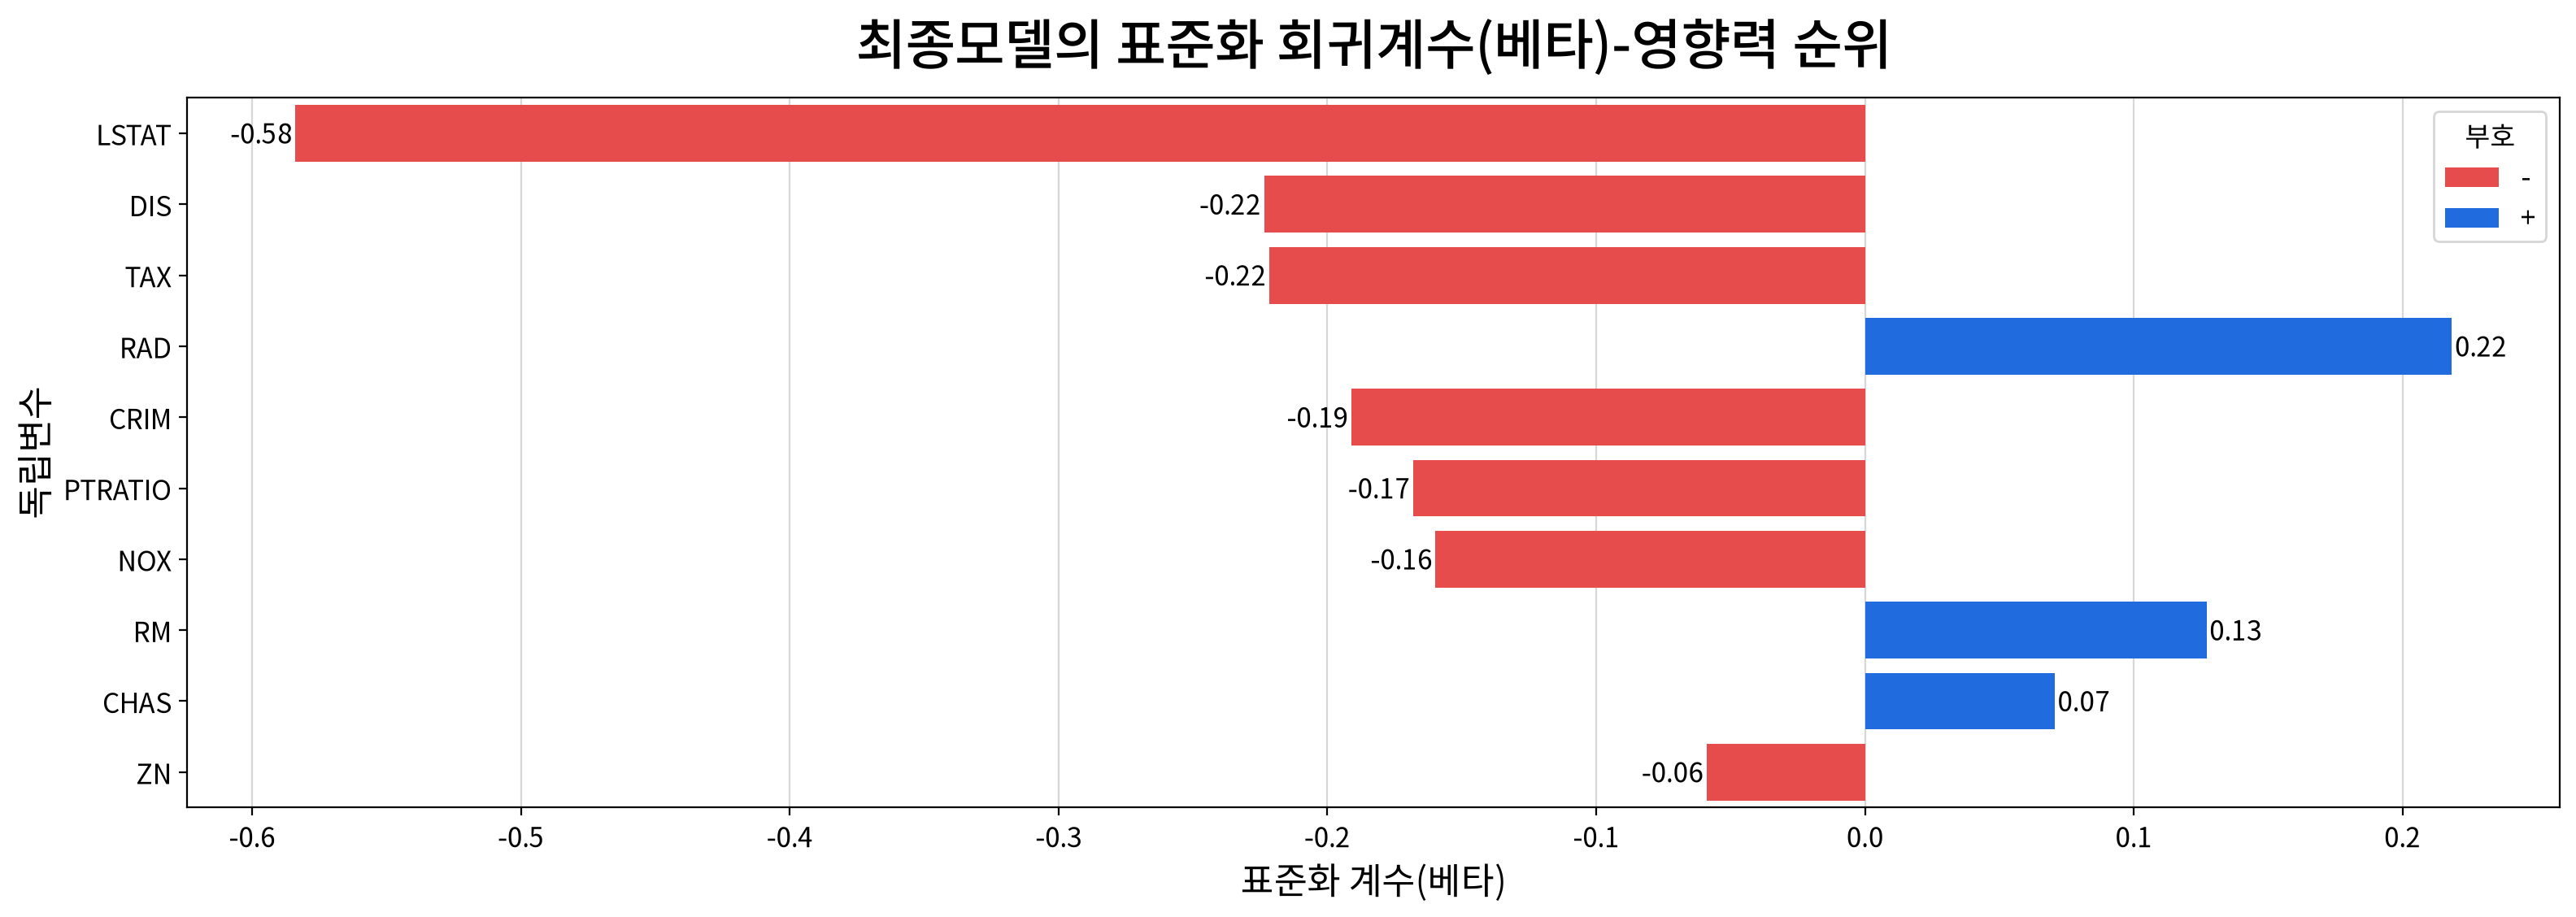

In [9]:
my_ols.plot_beta(final_fit, final_data, height=580, width=1600,
                 title="최종모델의 표준화 회귀계수(베타)-영향력 순위")

### 4. 회귀계수 해석 문장 

In [10]:
display(Markdown(
    my_ols.report_variables_text(final_fit, 
                                 log1p_y=True, 
                                 log_x=log_x, 
                                 log1p_x=log1p_x,
                                 reflect_x=reflect_x,
                                 hc3=final_fit.use_hc3_)
))

- **CRIM**의 회귀계수는 **B = -0.04**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -3.16**, **p = .002**)      
즉, CRIM가 **1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.04% 감소**하는 것으로 해석된다.
- **ZN**의 회귀계수는 **B = -0.01**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -2.24**, **p = .025**)      
즉, **(1+ZN)가 1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.01% 감소**하는 것으로 해석된다.
- **CHAS**의 회귀계수는 **B = 0.11**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = 2.89**, **p = .004**)      
즉, CHAS가 **1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **12.02% 증가**하는 것으로 해석된다.
- **NOX**의 회귀계수는 **B = -0.56**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -3.01**, **p = .003**)      
즉, NOX가 **1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **43.09% 감소**하는 것으로 해석된다.
- **RM**의 회귀계수는 **B = 0.07**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = 2.79**, **p = .005**)      
즉, RM가 **1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **7.67% 증가**하는 것으로 해석된다.
- **DIS**의 회귀계수는 **B = -0.17**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -4.37**, **p < .001**)      
즉, DIS가 **1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.17% 감소**하는 것으로 해석된다.
- **RAD**의 회귀계수는 **B = 0.1**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = 5.16**, **p < .001**)      
즉, RAD가 **1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.10% 증가**하는 것으로 해석된다.
- **TAX**의 회귀계수는 **B = -0.0**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -4.62**, **p < .001**)      
즉, TAX가 **1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.05% 감소**하는 것으로 해석된다.
- **PTRATIO**의 회귀계수는 **B = -0.03**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -7.1**, **p < .001**)      
즉, PTRATIO가 **1 증가**할 때 **(1+MEDV)**는 평균적으로 약 **3.13% 감소**하는 것으로 해석된다.
- **LSTAT**의 회귀계수는 **B = -0.4**으로 나타났으며, 이는 **MEDV**에 유의한 요인임을 의미한다. (**t(495) = -10.98**, **p < .001**)      
즉, LSTAT가 **1% 증가**할 때 **(1+MEDV)**는 평균적으로 약 **0.40% 감소**하는 것으로 해석된다.

> ※ **log1p**(=ln(1+·))의 % 해석은 변수 자체가 아니라 **(1+변수)** 기준이며, 값이 클 때만 위 근사가 성립한다.      
(0·작은 값 구간에서는 원본처럼 동작해 부정확)      
이 구간에서는 부호·유의성 중심으로 해석하거나 예측값을 expm1로 원 척도에서 비교한다.

> ※ **반사 후 log1p**(=ln(1+max-·))는 값의 대소가 뒤집힌 변환이다. 위 %·증감은 **(1+max-변수)** 기준이고,     
원 변수 기준 방향은 각 문장 끝 괄호에 적었다.      
변수가 **최댓값에 가까운 구간**에서는 위 근사가 부정확하므로 부호·유의성 중심으로 읽고,      
원 척도 값은 **max-(exp(변환값)-1)** 로 되돌려 비교한다.

> ※ 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해 **HC3 로버스트 표준오차**로 계산한 값이다.     
회귀계수(B)와 효과 크기 해석은 일반 OLS와 동일하며,     
표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다.

## #04. 최종 모델의 회귀분석 가정 검정 

### 1. 선형성 검정 

,statistic,p-value,linearity,result
Ramsey RESET,15.127,0.000,False,대립가설 채택 -> 선형성 위배 (곡선 관계 존재)


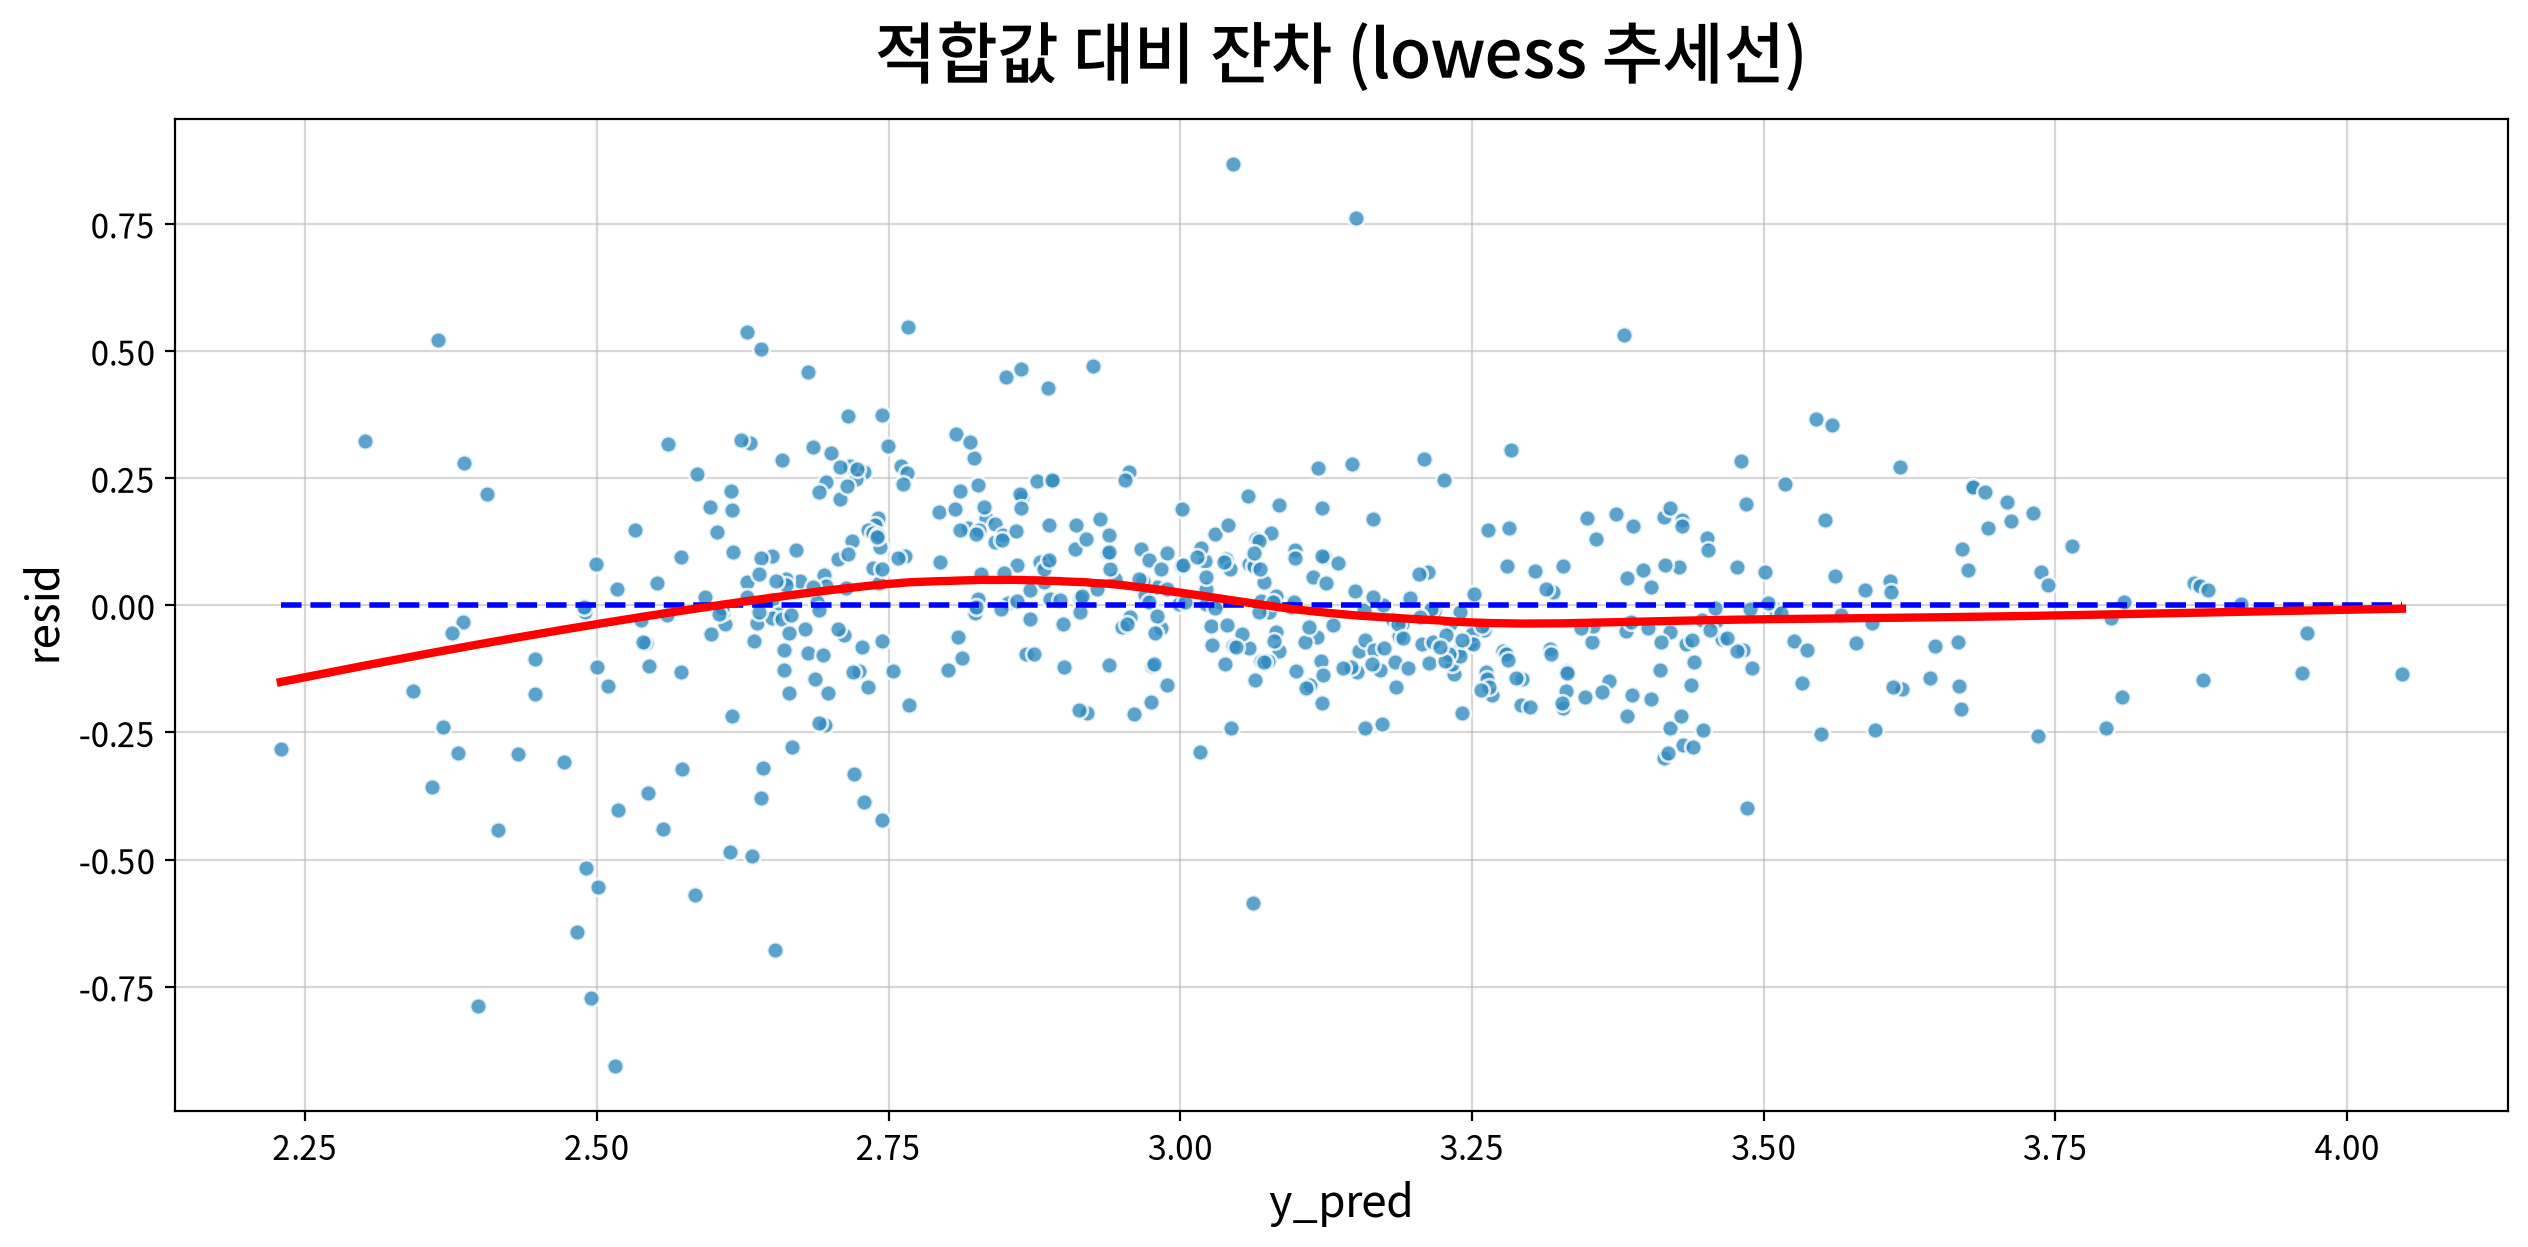

In [11]:
my_ols.test_linear(final_fit, plot=True, 
                   title="적합값 대비 잔차 (lowess 추세선)")

### 2. 정규성 검정 

,statistic,p-value,normality,result
kolmogorov-Smirnov,0.066,0.024,False,대립가설 채택 -> 정규성 위배


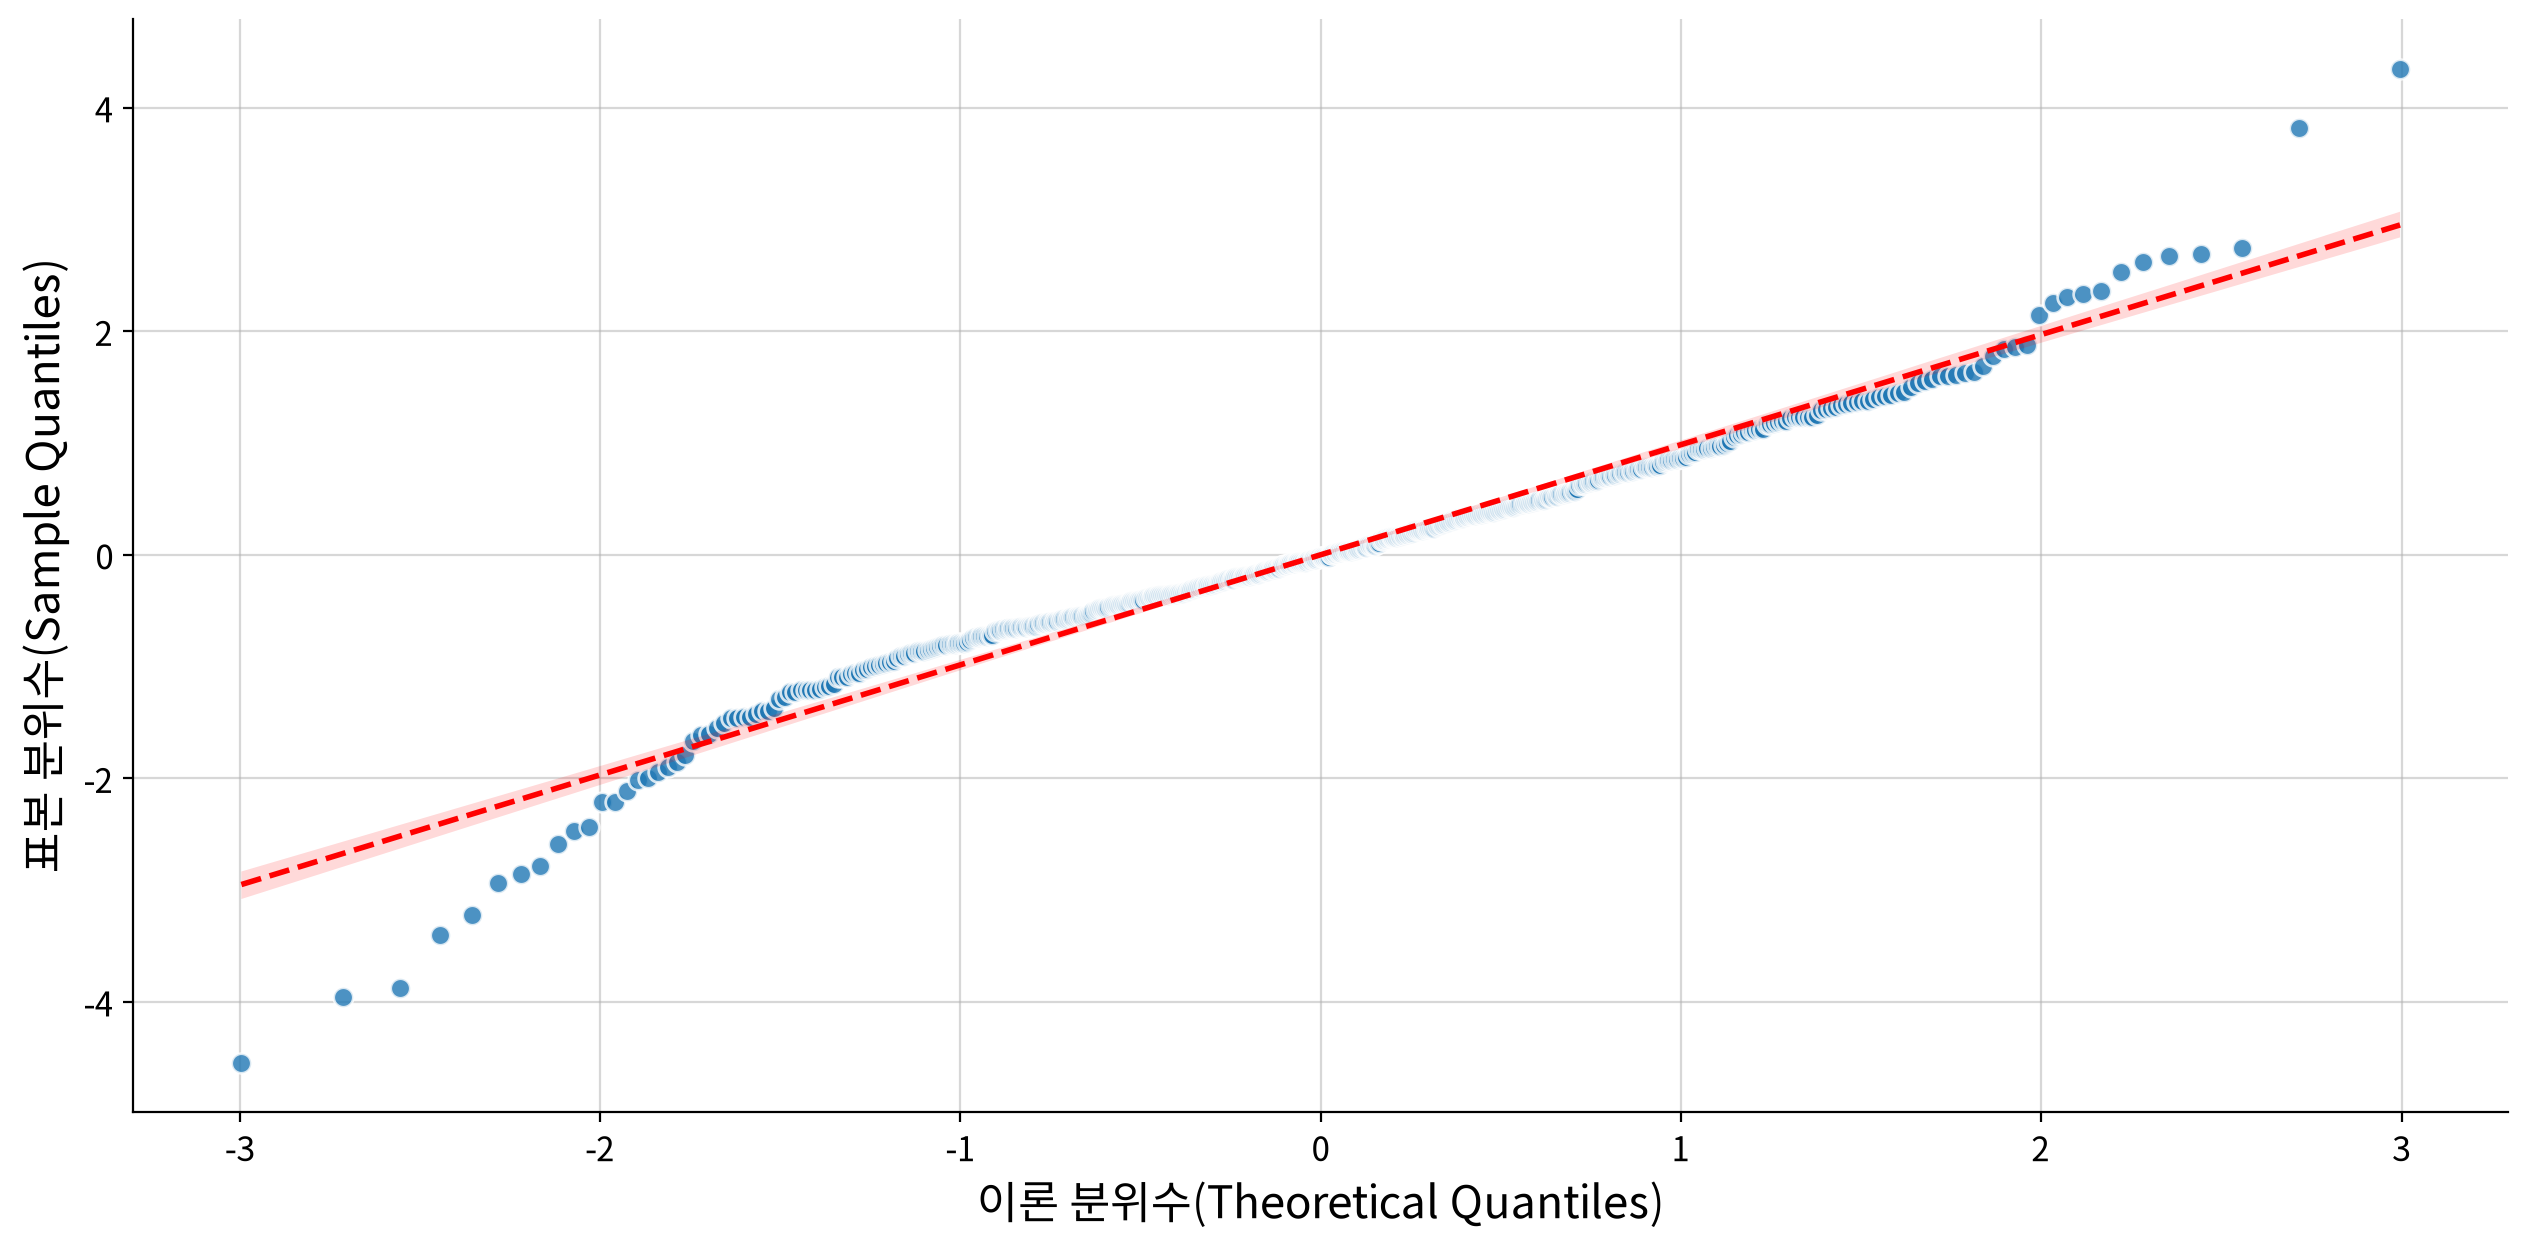

,기대(%),허용범위(%),실제(%),판정
구간,,,,
+-1루트MSE,68.000,64 ~ 72,76.680,위배
+-2루트MSE,95.000,93 ~ 97,94.860,충족
+-3루트MSE,99.700,99 ~ 100,98.620,위배


루트MSE = 0.20 , 구간 규칙 판정: 정규성 위배


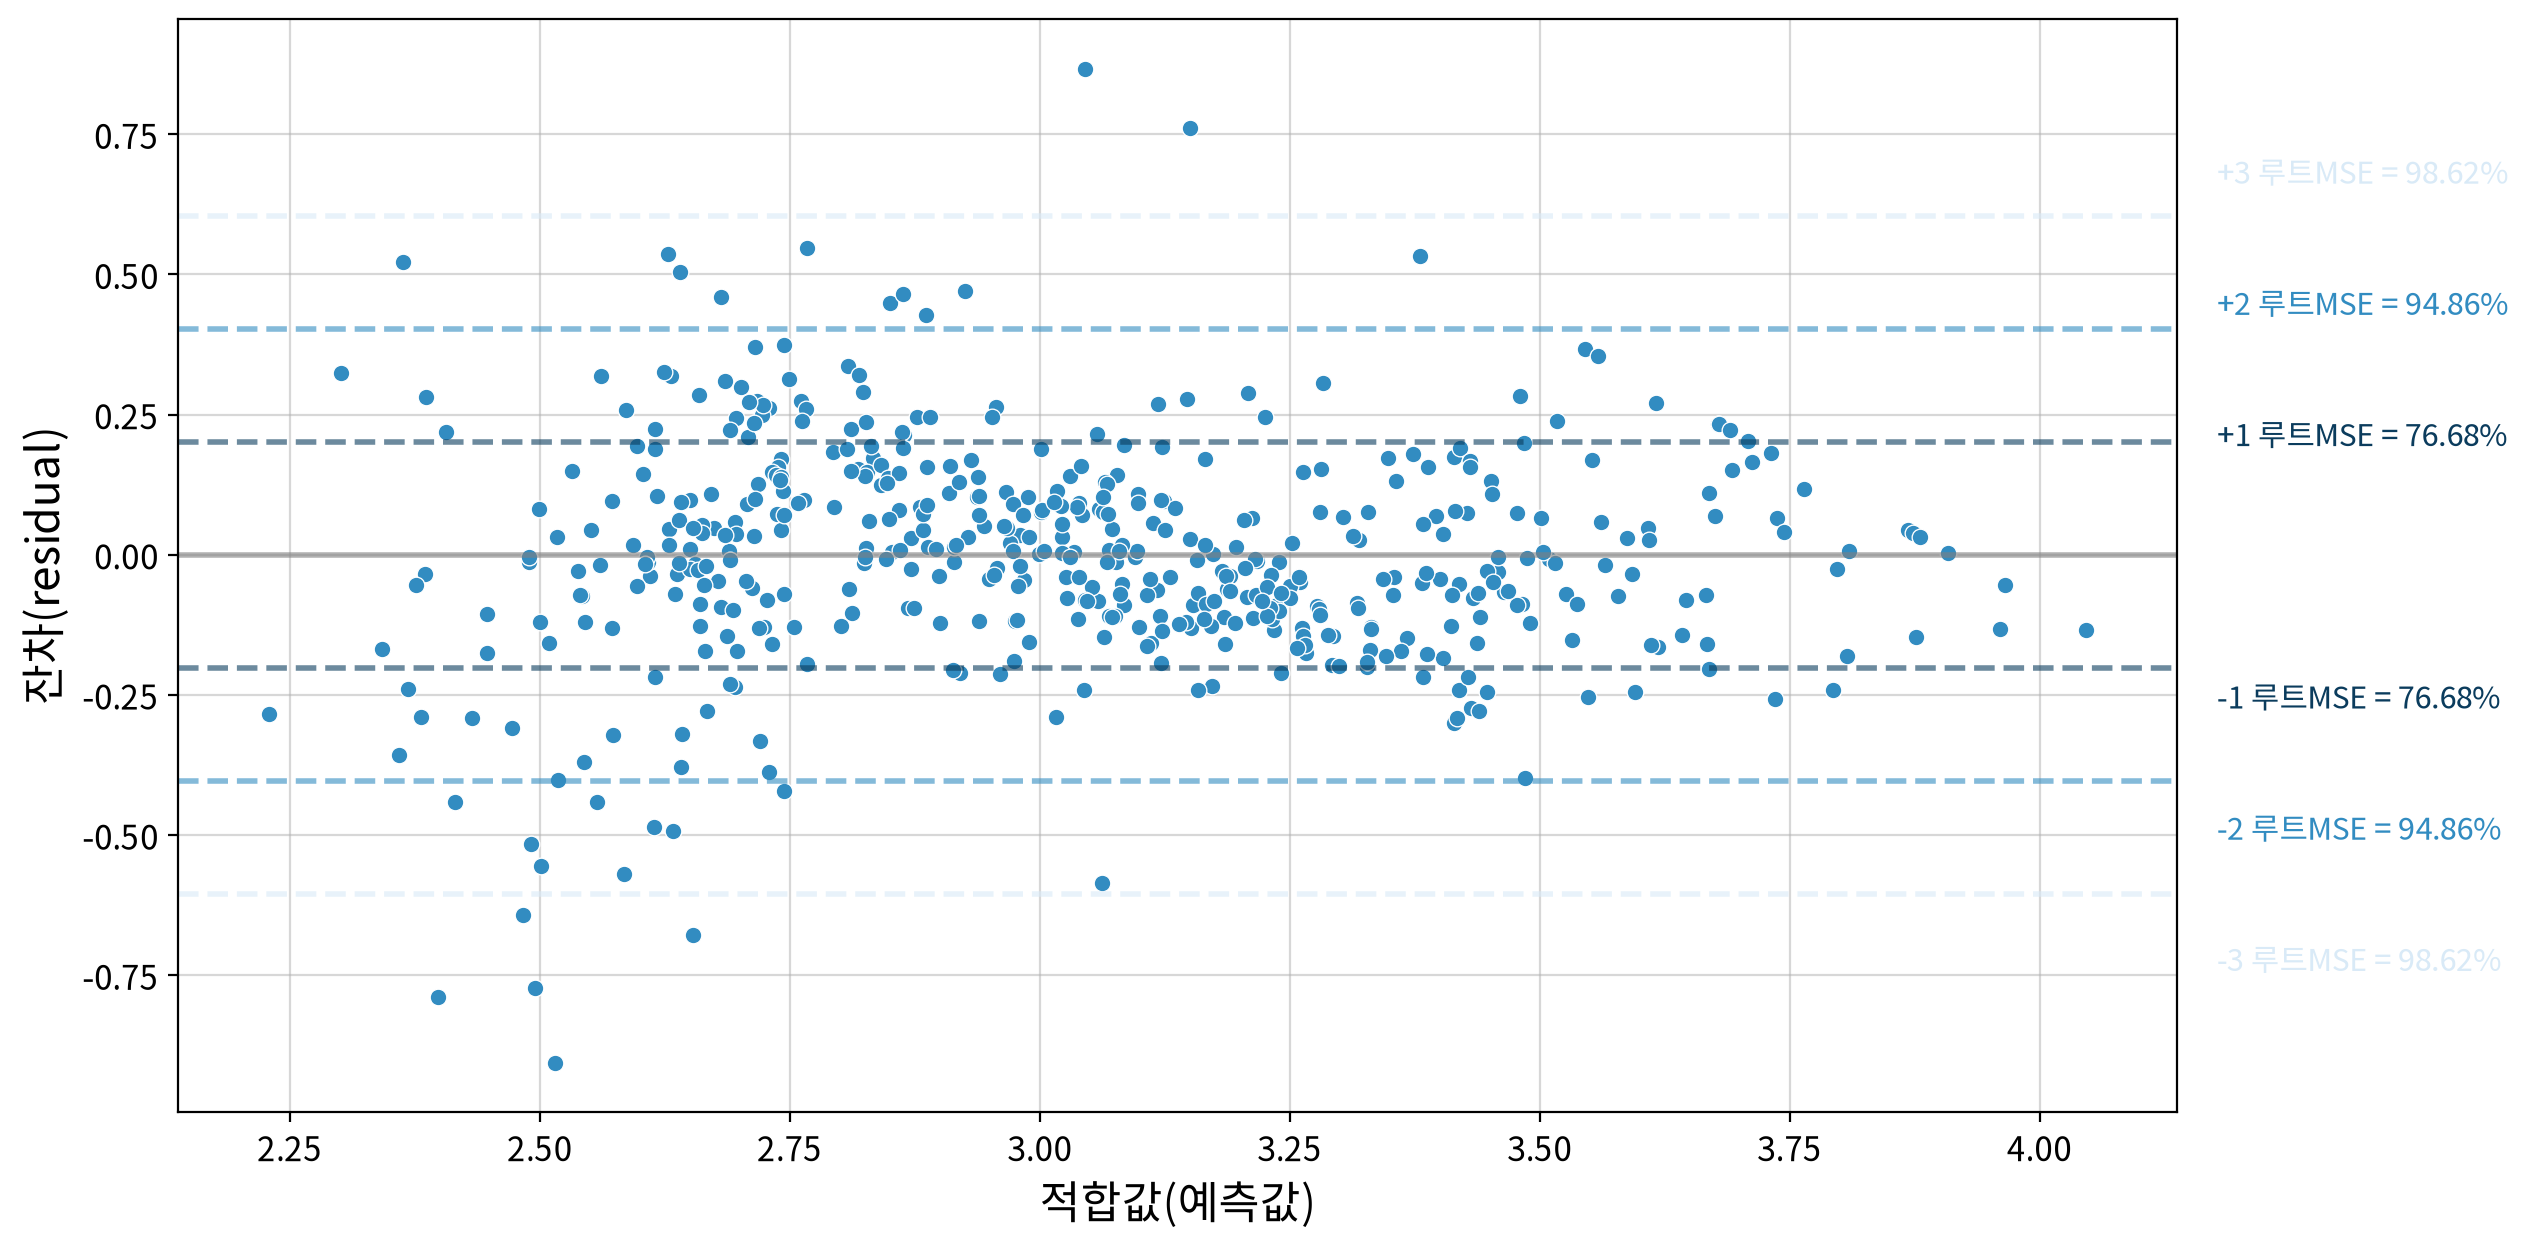

In [12]:
my_ols.test_normal(final_fit, plot=True)

### 3. 등분산성 검정 

In [13]:
my_ols.test_equalvar(final_fit)


,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,91.866,0.000,10.980,0.000,False,대립가설 채택 -> 등분산 아님


### 4. 독립성 검정 

In [14]:
my_ols.test_independent(final_fit)

,statistic,independence,result
Durbin-Watson,0.945,False,독립성 위반 (양(+)의 자기상관)


## #01 연습문제 

In [15]:
origin = load_data('insurance_qtcheck')
origin.head()

📚 보험 비용 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [16]:
desc = load_data('insurance_qtcheck_desc')
desc.head()

📚 보험 비용 데이터셋의 연속형 변수에 대한 기술 통계량 (출처: 자체 작업)


,count,mean,std,min,25%,50%,75%,max,rel_diff,rdiff_flag,iqr,upper_bound,lower_bound,upper_outliers,upper_outliers_ratio,lower_outliers,lower_outliers_ratio,outliers,outliers_ratio,skew,skew_interpret,kurt,kurt_interpret,log_need
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000,0.006,similar,24.000,87.000,-9.000,0,0.000,0,0.000,0,0.000,0.055,symmetric,-1.244,platykurtic,none
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130,0.009,similar,8.410,47.315,13.675,9,0.007,0,0.000,9,0.007,0.284,symmetric,-0.053,platykurtic,none
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000,0.096,similar,2.000,5.000,-3.000,0,0.000,0,0.000,0,0.000,0.937,right tail,0.201,leptokurtic,log1p
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428,0.415,diff,11911.373,34524.778,-13120.716,139,0.104,0,0.000,139,0.104,1.515,right tail,1.604,leptokurtic,log


In [17]:
cat_desc = load_data('insurance_qtcheck_category_desc')
cat_desc

📚 보험 비용 데이터셋의 범주형 변수에 대한 기술 통계량 (출처: 자체 작업)


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [18]:
# 명목형 기술통계량 표의 컬럼명이 곧 명목형 변수 목록이다
df = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       1337 non-null   int64   
 1   sex       1337 non-null   category
 2   bmi       1337 non-null   float64 
 3   children  1337 non-null   int64   
 4   smoker    1337 non-null   category
 5   region    1337 non-null   category
 6   charges   1337 non-null   float64 
dtypes: category(3), float64(2), int64(2)
memory usage: 46.0 KB


In [19]:
df0 = load_data("insurance_checkpoint_0")
df1 = load_data("insurance_checkpoint_1")
df2 = load_data("insurance_checkpoint_2")
df3 = load_data("insurance_checkpoint_3")
df4 = load_data("insurance_checkpoint_4")

📚 보험 비용 데이터셋의 전처리 체크포인트 0 - 기준선 역할을 위해 라벨링과 더미변수 처리만 적용됨
📚 보험 비용 데이터셋의 전처리 체크포인트 1 - 라벨링 + 더미변수 + 로그변환
📚 보험 비용 데이터셋의 전처리 체크포인트 2 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체
📚 보험 비용 데이터셋의 전처리 체크포인트 3 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체 + 다중공선성제거
📚 보험 비용 데이터셋의 전처리 체크포인트 4 - 라벨링 + 더미변수 + 로그변환 + 이상치 대체 + 다중공선성제거 + 스케일링


In [20]:
# 종속변수 
target = "charges"

# 비교 대상 체크포인트 (아래로 갈수록 전처리가 하나씩 누적된다.)
checkpoints = {"0_기준선":df0, "1_로그변환":df1, "2_이상치대체":df2, 
               "3_공선성제거":df3, "4_스케일링":df4}

# 앞 단원에서 확인된 내용 
# 종속변수(MEDV)에 log1p가 적용되었는지 여부 (체크포인트 1부터 적용됨)
log1p_y = {"0_기준선":False, "1_로그변환":True, "2_이상치대체":True, 
           "3_공선성제거":True, "4_스케일링":True}

# log1p가 적용된 독립변수 (기준선은 없고, 체크포인트 1부터 children에 적용됨)
log1p_x = {"0_기준선":[], "1_로그변환":["children"], "2_이상치대체":["children"],
           "3_공선성제거":["children"], "4_스케일링":["children"]}


# # 로그변환(log)이 적용된 독립변수 -> 최종 모델의 회귀계수 해석에 사용한다.
# log_x = ["CRIM", "DIS", "RAD", "LSTAT"]

# # 로그1p변환(log1p)이 적용된 독립변수 -> 최종 모델의 회귀계수 해석에 사용한다.
# log1p_x = ["ZN"]

# # 반전 로그 변환이 적용된 독립변수 
# reflect_x = ["B"]

In [21]:
charges_scale = DataFrame()

for name in checkpoints:
    data = checkpoints[name] 
    charges_scale[name] = data[target].describe() # 복사된 데이터에서 종속변수의 기술통계량만 구함 

charges_scale.round(3)

,0_기준선,1_로그변환,2_이상치대체,3_공선성제거,4_스케일링
count,1337.000,1337.000,1337.000,1337.000,1337.000
mean,13279.121,9.100,9.100,9.100,9.100
std,12110.360,0.919,0.919,0.919,0.919
min,1121.874,7.023,7.023,7.023,7.023
25%,4746.344,8.465,8.465,8.465,8.465
50%,9386.161,9.147,9.147,9.147,9.147
75%,16657.717,9.721,9.721,9.721,9.721
max,63770.428,11.063,11.063,11.063,11.063


In [22]:
# 보험료가 원래의 달러 금액이 아닌 다른 척도로 바뀌어 있는 데이터셋은 몇개인가 
# 기술통계를 구해, 값의 크기가 어디서 부터 달라지는지 본다
# 4 

In [23]:
fits = {}
result = [] 

for c in checkpoints:
    data = checkpoints[c] # 체크포인트 데이터프레임
    log = log1p_y[c] # 종속변수에 log1p가 적용되었는지 여부 

    # --- 1) 모델 적합 (후진제거 포함) ---
    fit = my_ols.auto_ols(data, target, 
                          log1p_y=log, log_x=log_x, log1p_x=log1p_x, reflect_x=reflect_x, 
                          backward=True, report=False, test=False)
    
    fits[c] = fit # 체크포인트별 학습 객체를 딕셔너리 형태로 저장한다

    # --- 2) 실제값과 예측값을 원본 척도(천 달러)로 되돌린다 ---
    if log : 
        y_true = np.expm1(data[target]) # 종속변수 역변환
        y_pred = np.expm1(fit.fittedvalues) # 예측값 역변환
    else:
        y_true = data[target]   # 체크포인트 0은 이미 원본 척도 
        y_pred = fit.fittedvalues 

    # --- 3) 지표를 한 행으로 정리해 저장 ---
    result.append({
        "모델": c, 
        "변수수": int(fit.df_model), # 상수항을 제외한 독립변수 개수
        "R2(모델척도)": fit.rsquared, # 체크포인트간 빅 불가 (참고용)
        "Adj.R2": fit.rsquared_adj, # 같은 종속변수끼리만 비교
        "AIC": fit.aic, # 같은 종속변수끼리만 비교(작을 수록 좋음)
        "BIC": fit.bic, # 같은 종속변수끼리만 비교 (작을수록 좋음)
        # 아래 세 지표는 원본 척도에서 계산하므로 체크포인트간 비교가 가능하다 
        "R2(원본척도)": r2_score(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred), # 최종 선택 기준
        "MAE": mean_absolute_error(y_true, y_pred),
    })
rdf = DataFrame(result).set_index("모델")
rdf.round(4)

,변수수,R2(모델척도),Adj.R2,AIC,BIC,R2(원본척도),RMSE,MAE
모델,,,,,,,,
0_기준선,4,0.750,0.749,27092.752,27118.743,0.750,6058.641,4181.335
1_로그변환,4,0.763,0.762,1653.311,1679.302,0.532,8281.267,4247.790
2_이상치대체,4,0.763,0.762,1652.808,1678.799,0.532,8278.466,4248.574
3_공선성제거,4,0.763,0.762,1652.808,1678.799,0.532,8278.466,4248.574
4_스케일링,4,0.763,0.762,1652.808,1678.799,0.532,8278.466,4248.574


In [24]:
# 문제2 
# 모델 척도의 설명력만 봤을때, 가장 높은 설명력은
# 0.763

# 같은 척도가 아니면, AIC, BIC 비교는 의미 없음 

In [25]:
# 문제 3
# 0.763 짜리 모형들의 예측값을 원래의 달러 금액으로 되돌린 뒤
# 설명력을 다시 계산하면 얼마인가 
# 0.532 

In [26]:
# 문제 4
# 실제 청구 단위인 달러로 되돌려 평균적인 예측 오차(RMSE)를 비교했을때
# 최종 요율 모형으로 채택해야 할 데이터셋은 어느 체크포인트 인가
# 0_기준선 

In [ ]:
# 최종 모형의 회귀계수와 영향력 순위 
final_name = "0_기준선"

final_fit = fits[final_name]
final_data = checkpoints[final_name]

print(f"최종 모형: {final_name} | 등분산 위배(HC3 사용) = {final_fit.use_hc3_}")

my_ols.report_variables(final_fit, final_data, hc3=final_fit.use_hc3_)

최종 모형: 0_기준선 | 등분산 위배(HC3 사용) = True


,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,charges,smoker,23810.399,411.414,573.837,0.794,57.875,41.493,0.000,0.000,0.999,1.001
1,charges,age,257.773,11.910,11.877,0.299,21.644,21.704,0.000,0.000,0.986,1.014
2,charges,bmi,321.871,27.388,30.077,0.162,11.752,10.702,0.000,0.000,0.988,1.012
3,charges,children,472.975,137.879,131.271,0.047,3.430,3.603,0.001,0.000,0.998,1.002


In [ ]:
# 최종 모형의 회귀분석 가정 검정 
my_ols.test_linear(final_fit, plot=False)   # 1) 선형성
my_ols.test_normal(final_fit, plot=False)   # 2) 정규성
my_ols.test_equalvar(final_fit)             # 3) 등분산성 
my_ols.test_independent(final_fit)          # 4) 독립성 

,statistic,p-value,linearity,result
Ramsey RESET,141.672,0.000,False,대립가설 채택 -> 선형성 위배 (곡선 관계 존재)


,statistic,p-value,normality,result
kolmogorov-Smirnov,0.163,0.000,False,대립가설 채택 -> 정규성 위배


,기대(%),허용범위(%),실제(%),판정
구간,,,,
+-1루트MSE,68.000,65 ~ 71,73.000,위배
+-2루트MSE,95.000,94 ~ 96,94.690,충족
+-3루트MSE,99.700,99 ~ 100,97.980,위배


루트MSE = 6070.00 , 구간 규칙 판정: 정규성 위배


,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,116.980,0.000,31.929,0.000,False,대립가설 채택 -> 등분산 아님


,statistic,independence,result
Durbin-Watson,2.088,True,독립성 만족


In [29]:
final_fit = fits["0_기준선"]
final_data = checkpoints["0_기준선"]

In [30]:
display(Markdown(
    my_ols.report_fitness(final_fit, log1p_y=True, log_x=log_x, 
                          log1p_x=log1p_x, reflect_x=reflect_x)
))

**Note. n = 1337. F(4, 1332) = 996.48, p < 0.001, R² = 0.75, Adj.R² = 0.749, Durbin-Watson = 2.088**

log1p(charges)를 종속변수로, age, bmi, children, smoker(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(4, 1332) = 996.48, p < 0.001, R² = 0.75.

즉, age, bmi, children, smoker는 log1p(charges)의 약 74.95%를 설명하는 것으로 나타났다.

In [ ]:
my_ols.report_variables(final_fit, final_data, hc3=final_fit.use_hc3_)

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,charges,smoker,23810.399,411.414,573.837,0.794,57.875,41.493,0.000,0.000,0.999,1.001
1,charges,age,257.773,11.910,11.877,0.299,21.644,21.704,0.000,0.000,0.986,1.014
2,charges,bmi,321.871,27.388,30.077,0.162,11.752,10.702,0.000,0.000,0.988,1.012
3,charges,children,472.975,137.879,131.271,0.047,3.430,3.603,0.001,0.000,0.998,1.002


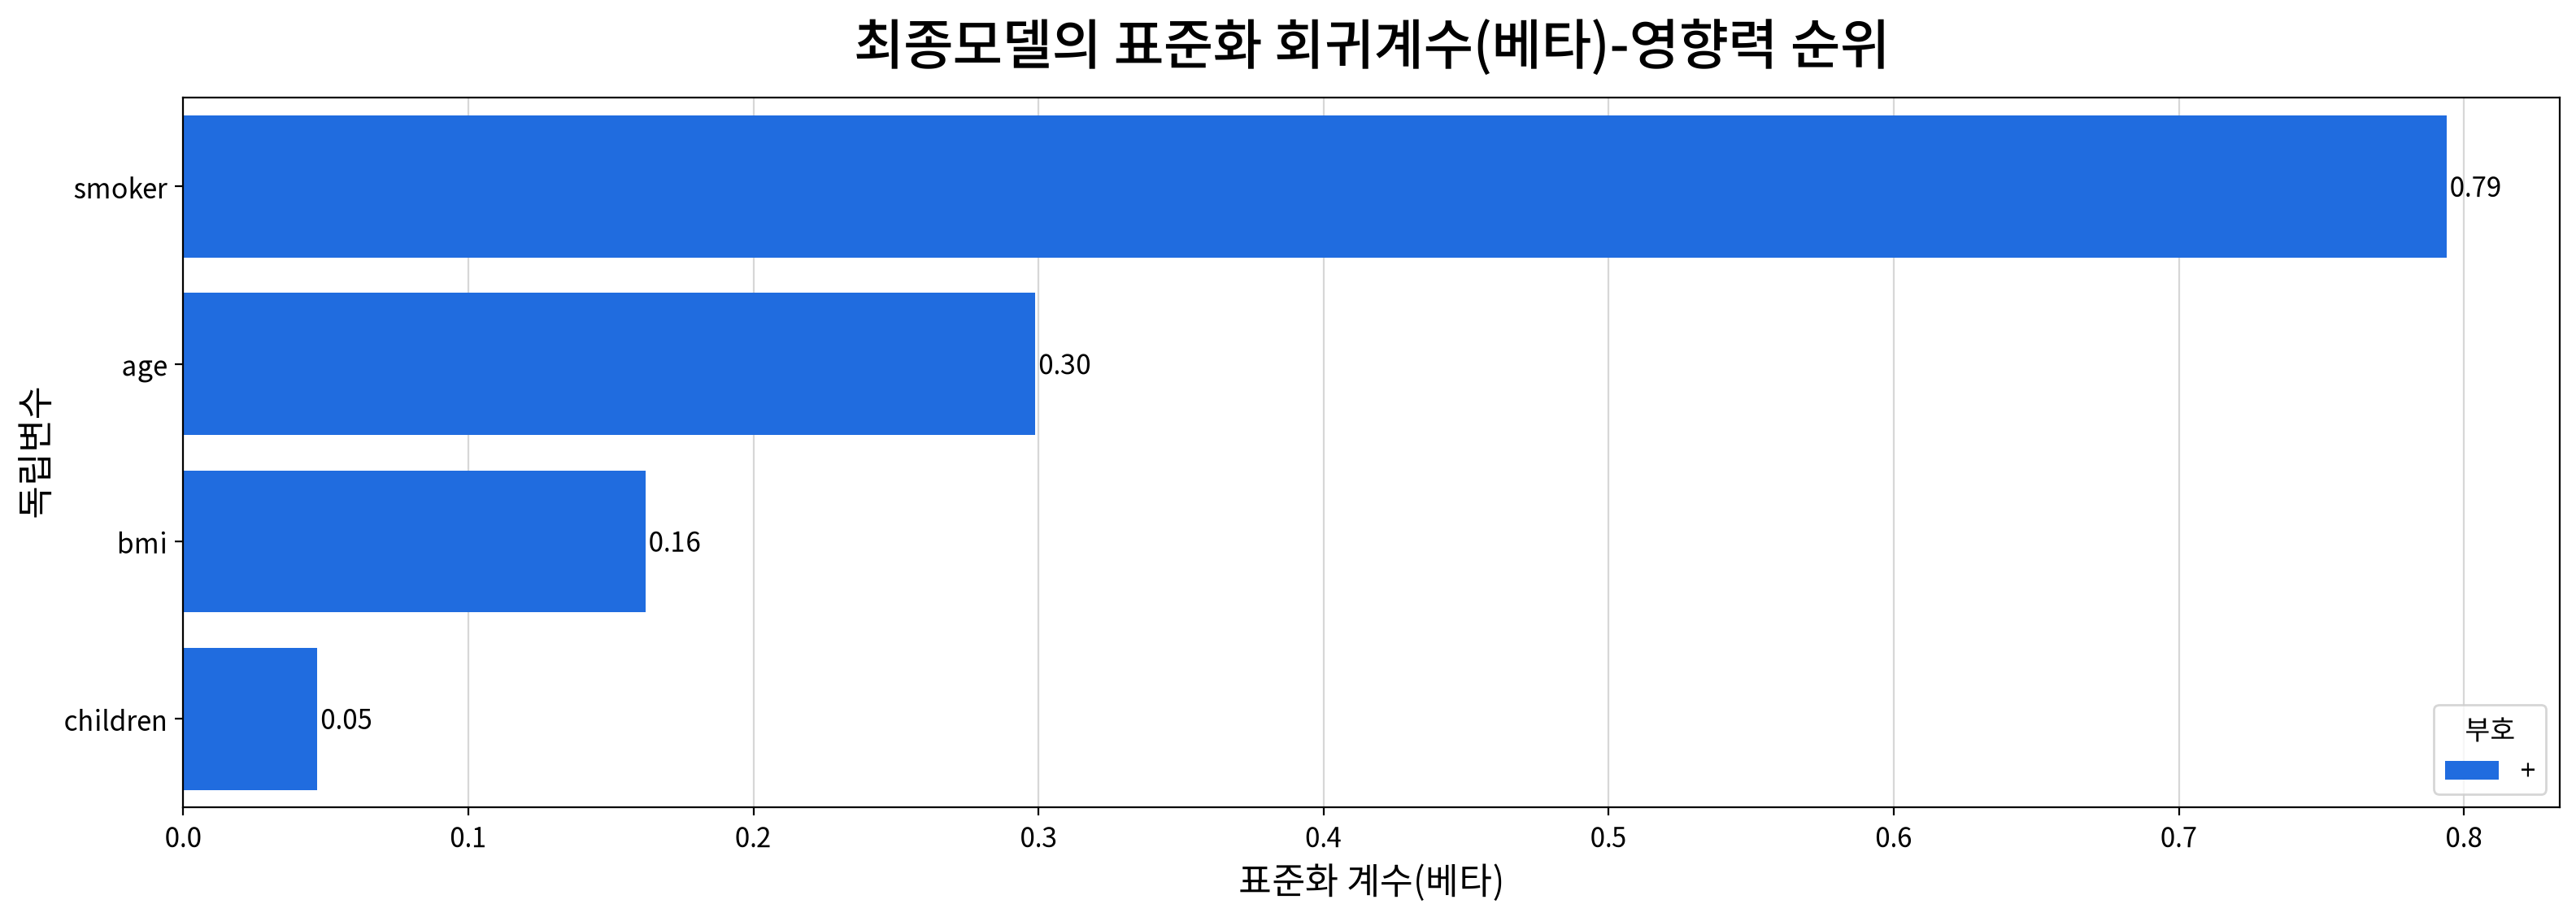

In [32]:
my_ols.plot_beta(final_fit, final_data, height=580, width=1600,
                 title="최종모델의 표준화 회귀계수(베타)-영향력 순위")

In [33]:
# 문제5 
# 채택한 모형에서 보험료에 미치는 영향력이 가장 큰 변수는 
# smoker 

In [34]:
display(Markdown(
    my_ols.report_variables_text(final_fit, 
                                 log1p_y=True, 
                                 log_x=log_x, 
                                 log1p_x=log1p_x,
                                 reflect_x=reflect_x,
                                 hc3=final_fit.use_hc3_)
))

C:\py_temp\15_LAB\helpers\my_ols.py:668: RuntimeWarning: overflow encountered in exp
  mag, unit, approx = f"{abs((np.exp(B) - 1) * 100):.2f}", "%", "약 "


- **age**의 회귀계수는 **B = 257.77**으로 나타났으며, 이는 **charges**에 유의한 요인임을 의미한다. (**t(1332) = 21.7**, **p < .001**)      
즉, age가 **1 증가**할 때 **(1+charges)**는 평균적으로 약 **889841116372272569060338638285646976097071564260059755631624324264805976155648262913622172076255708503302972899328.00% 증가**하는 것으로 해석된다.
- **bmi**의 회귀계수는 **B = 321.87**으로 나타났으며, 이는 **charges**에 유의한 요인임을 의미한다. (**t(1332) = 10.7**, **p < .001**)      
즉, bmi가 **1 증가**할 때 **(1+charges)**는 평균적으로 약 **6119472250561423204623079542350096911660030838830532525074578022374176370481990570854164585294660793198612975611041165926692699310619147370496.00% 증가**하는 것으로 해석된다.
- **children**의 회귀계수는 **B = 472.98**으로 나타났으며, 이는 **charges**에 유의한 요인임을 의미한다. (**t(1332) = 3.6**, **p < .001**)      
즉, children가 **1 증가**할 때 **(1+charges)**는 평균적으로 약 **2573107316800979585076574044678881447177337462053973921356183827258270733927291345065908464662339573676630800055125584810269235482965293031127476868028898415100472574056345994373853348506430827293953409155072.00% 증가**하는 것으로 해석된다.
- **smoker**의 회귀계수는 **B = 23810.4**으로 나타났으며, 이는 **charges**에 유의한 요인임을 의미한다. (**t(1332) = 41.49**, **p < .001**)      
즉, smoker가 **1 증가**할 때 **(1+charges)**는 평균적으로 약 **inf% 증가**하는 것으로 해석된다.

> ※ **log1p**(=ln(1+·))의 % 해석은 변수 자체가 아니라 **(1+변수)** 기준이며, 값이 클 때만 위 근사가 성립한다.      
(0·작은 값 구간에서는 원본처럼 동작해 부정확)      
이 구간에서는 부호·유의성 중심으로 해석하거나 예측값을 expm1로 원 척도에서 비교한다.

> ※ **반사 후 log1p**(=ln(1+max-·))는 값의 대소가 뒤집힌 변환이다. 위 %·증감은 **(1+max-변수)** 기준이고,     
원 변수 기준 방향은 각 문장 끝 괄호에 적었다.      
변수가 **최댓값에 가까운 구간**에서는 위 근사가 부정확하므로 부호·유의성 중심으로 읽고,      
원 척도 값은 **max-(exp(변환값)-1)** 로 되돌려 비교한다.

> ※ 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해 **HC3 로버스트 표준오차**로 계산한 값이다.     
회귀계수(B)와 효과 크기 해석은 일반 OLS와 동일하며,     
표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다.

In [35]:
display(Markdown(
    my_ols.report_fitness(final_fit, log1p_y=True, log_x=log_x, 
                          log1p_x=log1p_x, reflect_x=reflect_x)
))

**Note. n = 1337. F(4, 1332) = 996.48, p < 0.001, R² = 0.75, Adj.R² = 0.749, Durbin-Watson = 2.088**

log1p(charges)를 종속변수로, age, bmi, children, smoker(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(4, 1332) = 996.48, p < 0.001, R² = 0.75.

즉, age, bmi, children, smoker는 log1p(charges)의 약 74.95%를 설명하는 것으로 나타났다.

In [36]:
my_ols.report_variables(final_fit, final_data, hc3=final_fit.use_hc3_)

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,charges,smoker,23810.399,411.414,573.837,0.794,57.875,41.493,0.000,0.000,0.999,1.001
1,charges,age,257.773,11.910,11.877,0.299,21.644,21.704,0.000,0.000,0.986,1.014
2,charges,bmi,321.871,27.388,30.077,0.162,11.752,10.702,0.000,0.000,0.988,1.012
3,charges,children,472.975,137.879,131.271,0.047,3.430,3.603,0.001,0.000,0.998,1.002


,statistic,p-value,linearity,result
Ramsey RESET,141.672,0.000,False,대립가설 채택 -> 선형성 위배 (곡선 관계 존재)


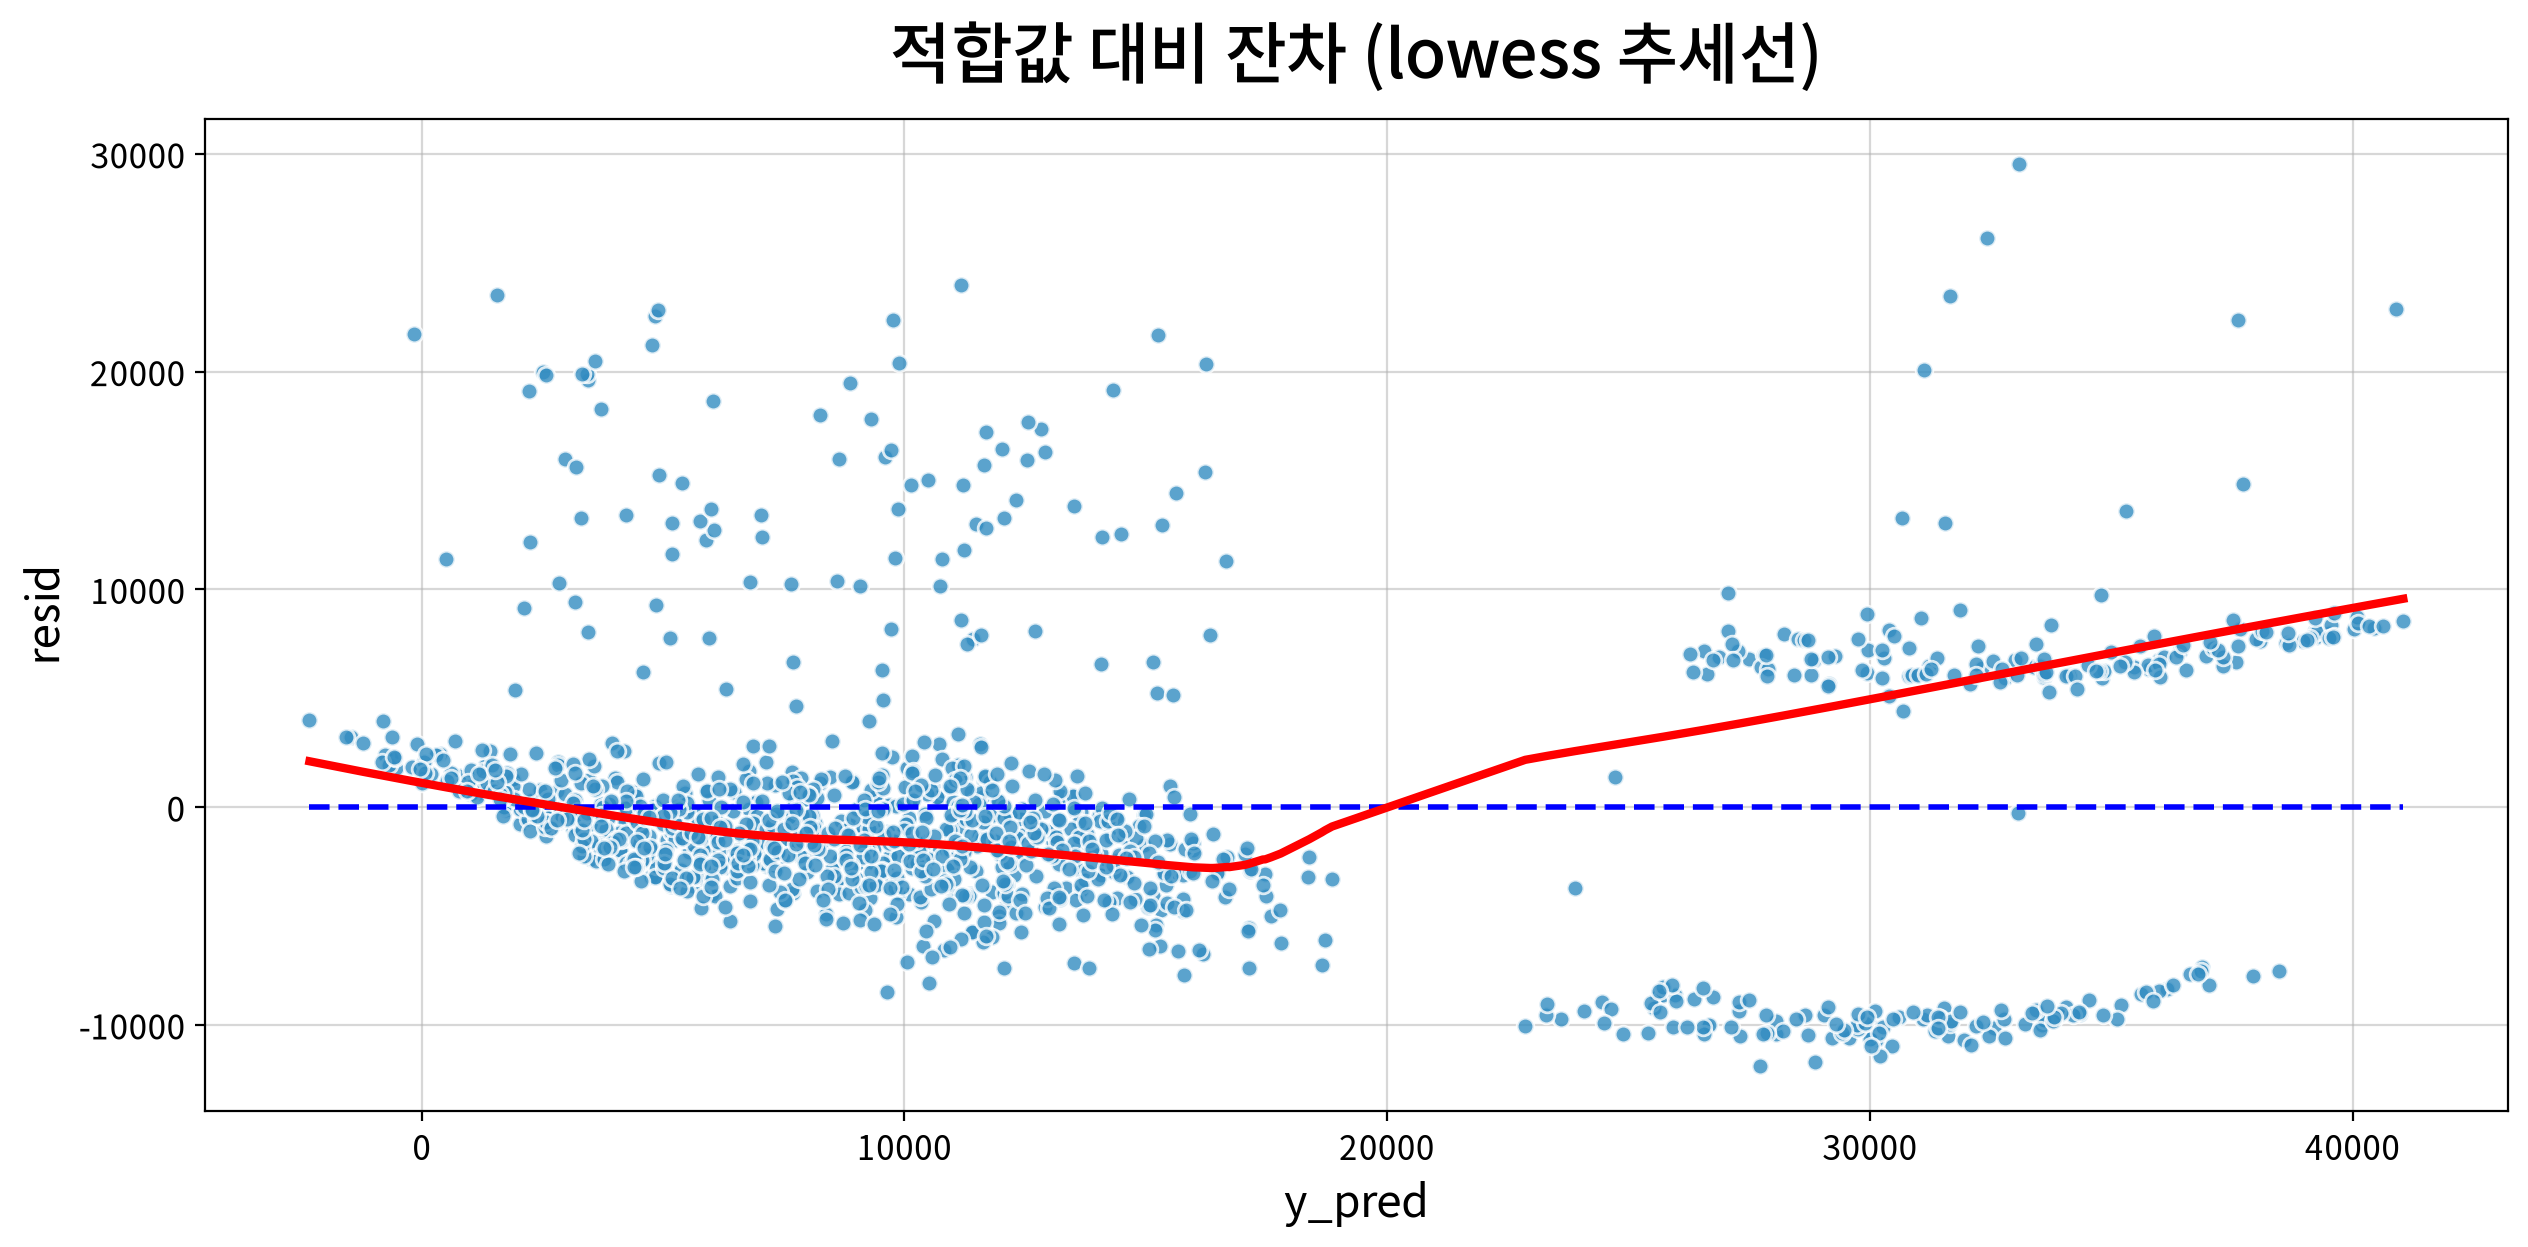

In [37]:
my_ols.test_linear(final_fit, plot=True, 
                   title="적합값 대비 잔차 (lowess 추세선)")

,statistic,p-value,normality,result
kolmogorov-Smirnov,0.163,0.000,False,대립가설 채택 -> 정규성 위배


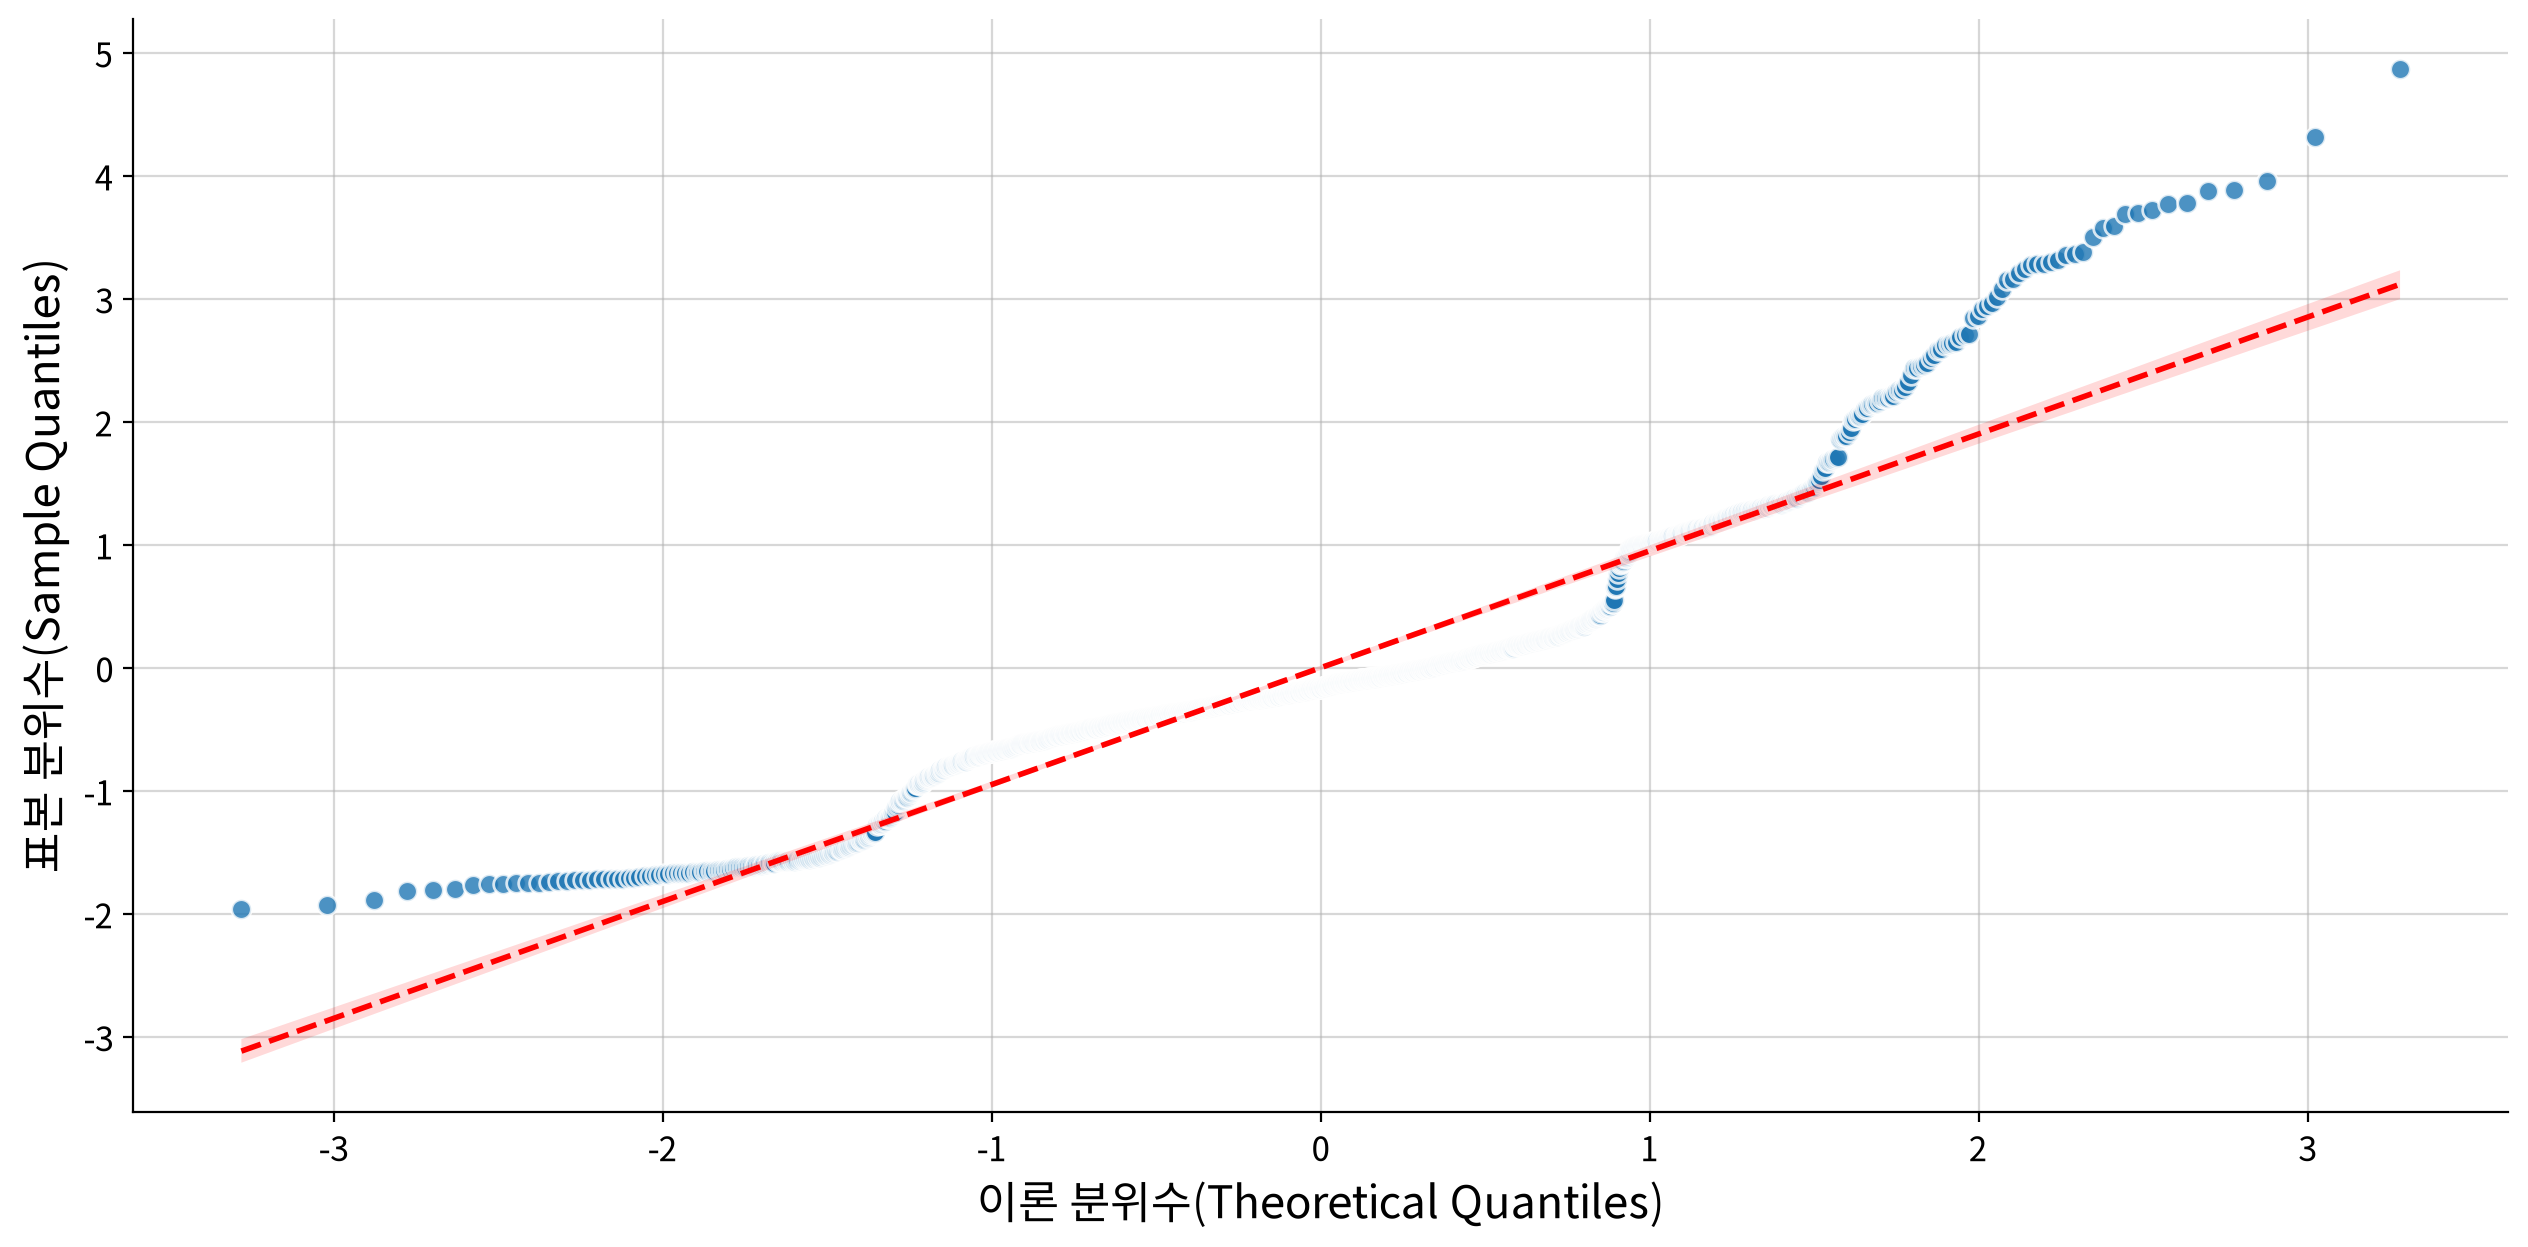

,기대(%),허용범위(%),실제(%),판정
구간,,,,
+-1루트MSE,68.000,65 ~ 71,73.000,위배
+-2루트MSE,95.000,94 ~ 96,94.690,충족
+-3루트MSE,99.700,99 ~ 100,97.980,위배


루트MSE = 6070.00 , 구간 규칙 판정: 정규성 위배


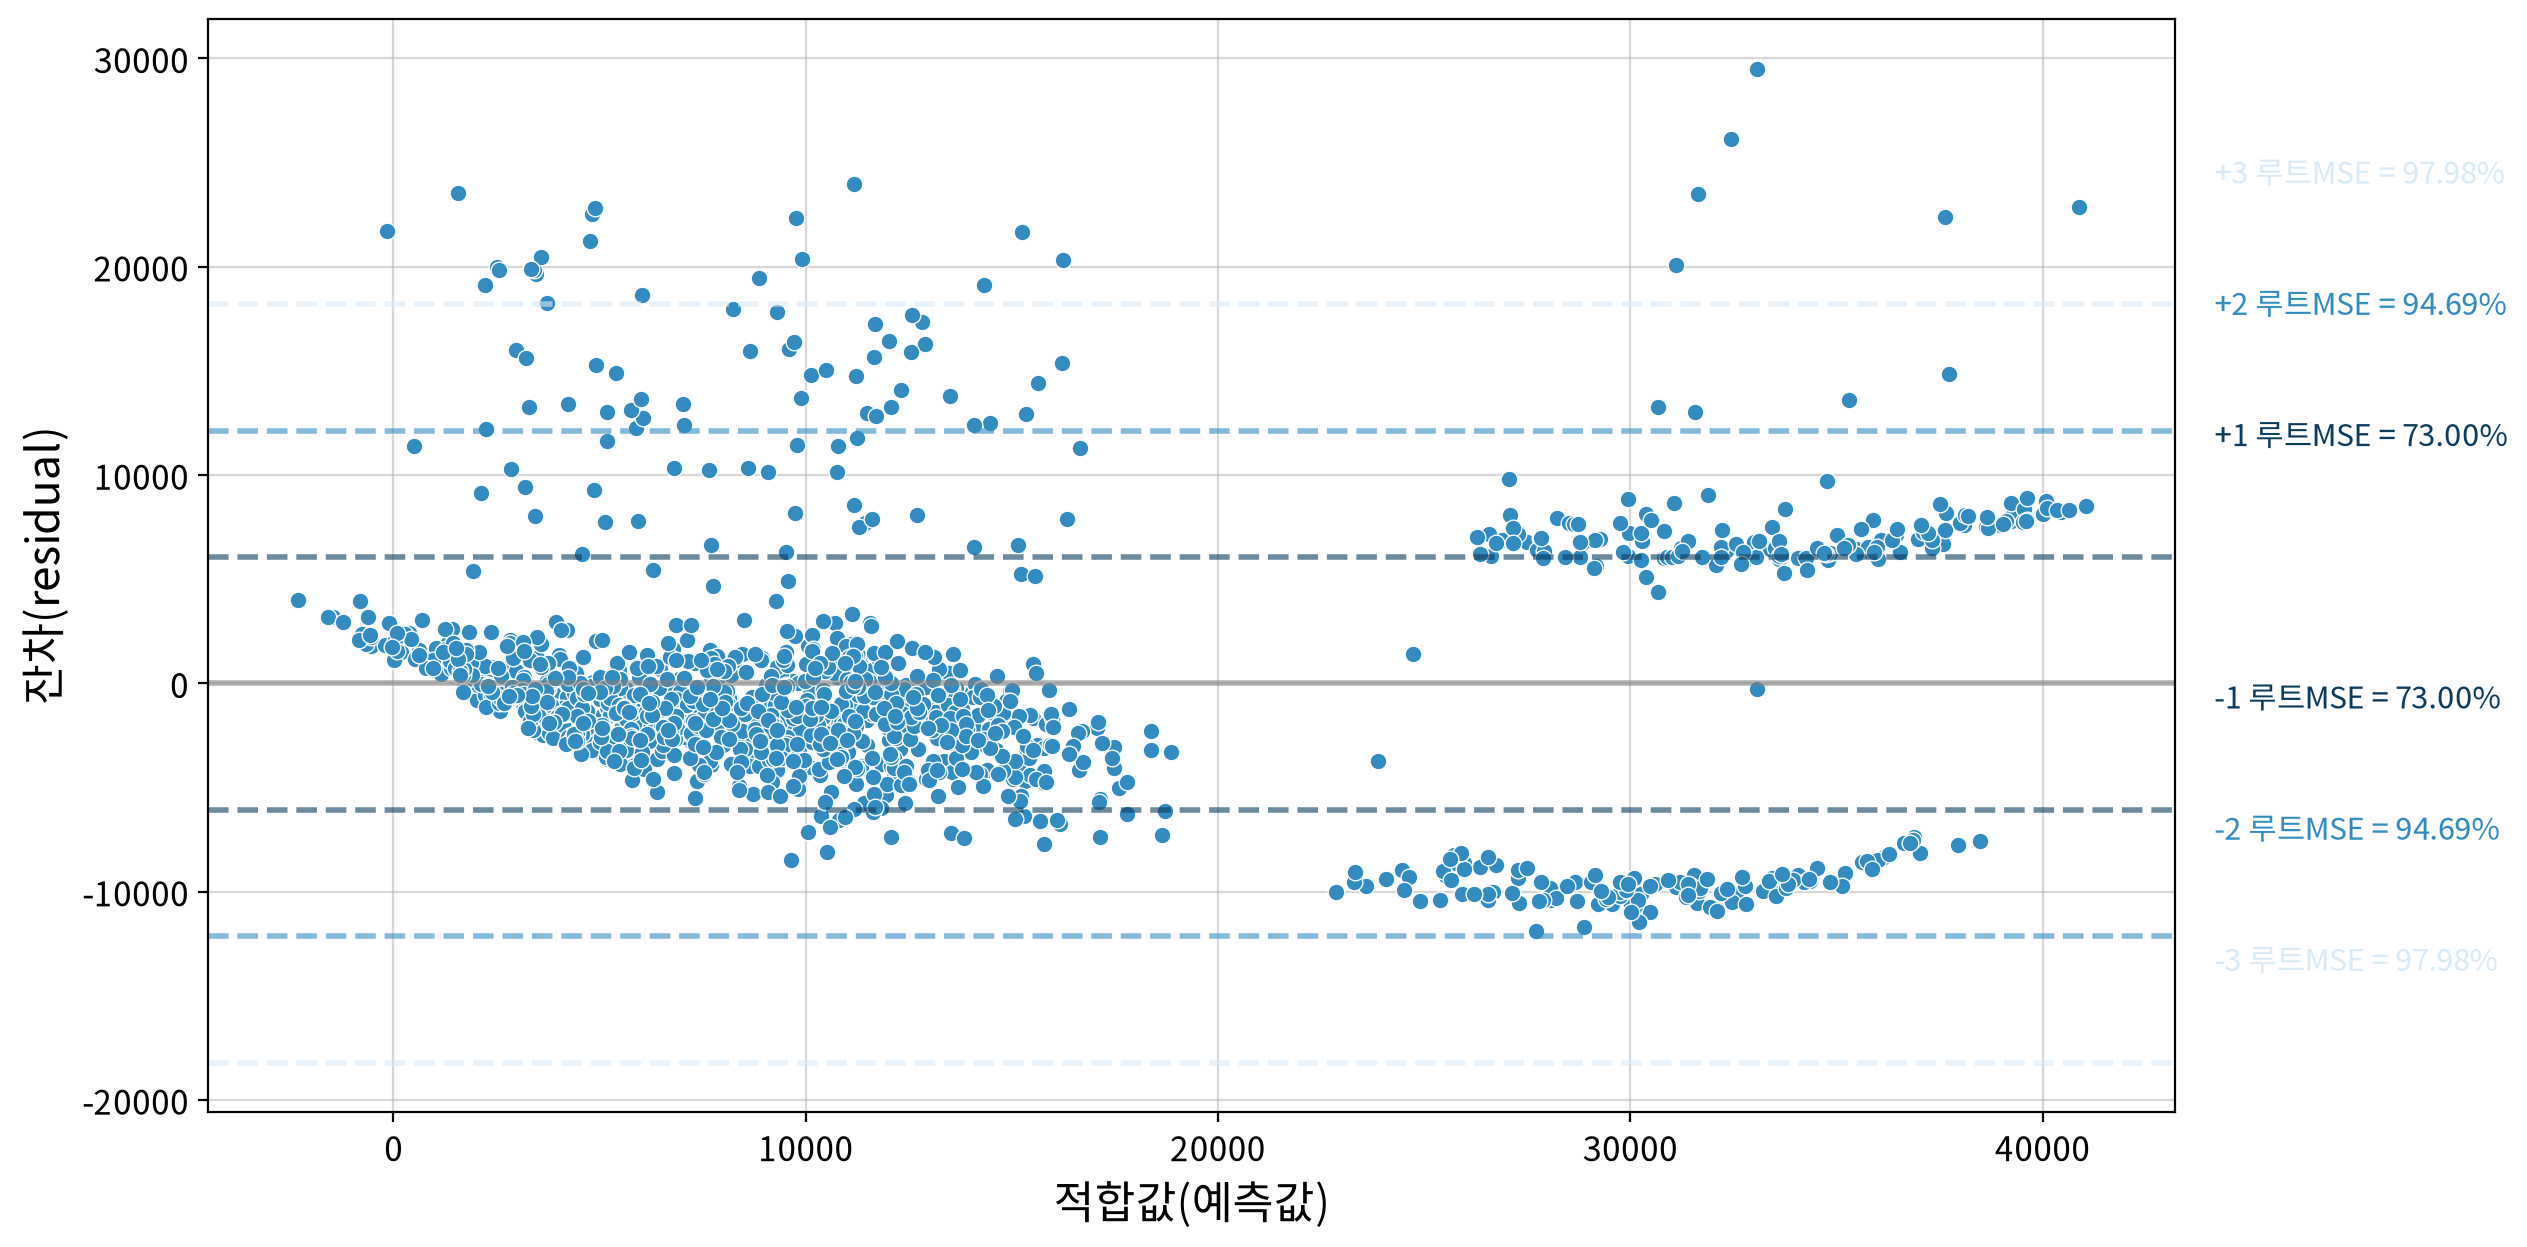

In [38]:
my_ols.test_normal(final_fit, plot=True)

In [39]:
my_ols.test_equalvar(final_fit)


,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,116.980,0.000,31.929,0.000,False,대립가설 채택 -> 등분산 아님


In [40]:
my_ols.test_independent(final_fit)

,statistic,independence,result
Durbin-Watson,2.088,True,독립성 만족


In [41]:
# 문제4 
# 4가지 회귀분석 후, 충족된 가정은 
# 독립성 